<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/guia36_BIY7121_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guía 3.6 — Actividad Formativa Visualización
**Asignatura:** BIY7121 Minería de Datos  
**EA:** Evaluación y Difusión de Modelos  
**Dataset:** Brazilian E-Commerce Public Dataset (Olist)  

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#1a6496', '#e67e22', '#27ae60', '#8e44ad', '#c0392b', '#16a085']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 110
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 0. Carga y preparación del dataset

El dataset de Olist tiene transacciones reales de e-commerce brasileño entre 2016 y 2018. Todo viene en un solo CSV: órdenes, clientes, pagos y productos. Primero cargamos y limpiamos las fechas para poder usarlas bien después.

In [4]:
df = pd.read_csv('Brazilian E-Commerce Public Dataset.csv')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

# Convertir fechas
for col in ['order_purchase_timestamp', 'order_delivered_customer_date',
            'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Extraer hora y día de la semana desde el timestamp de compra
df['hour_of_purchase']    = df['order_purchase_timestamp'].dt.hour
df['weekday_of_purchase'] = df['order_purchase_timestamp'].dt.day_name()

# Días de entrega real
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

print(f'Rango: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')
print(f'Nulos en columnas clave: {df[["customer_unique_id","payment_value","product_category_name"]].isnull().sum().sum()}')
df.head()

Filas: 113,390  |  Columnas: 39
Rango: 2016-10-03 → 2018-08-29
Nulos en columnas clave: 0


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id,hour_of_purchase,weekday_of_purchase,delivery_days
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-29,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1,8,Wednesday,7
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-07-26,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1,11,Wednesday,15
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-06-07,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1,10,Friday,17
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-25,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1,18,Tuesday,8
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-01,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1,21,Thursday,13


---
## 1. Exploración de Datos

### 1.1 Análisis Geográfico

Brasil es un país enorme, así que tiene sentido ver dónde está concentrada la actividad. Agrupamos por estado y ciudad para identificar los mercados más importantes.

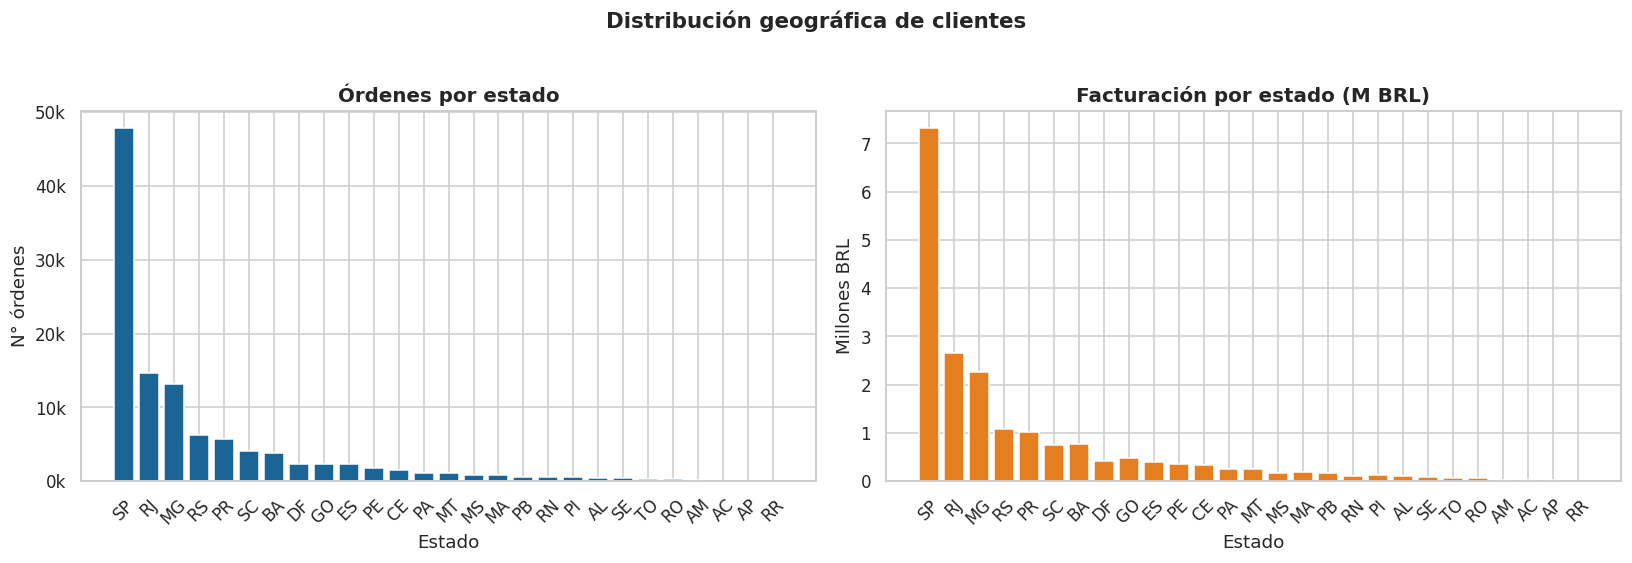

customer_state  ordenes    revenue
            SP    47830 7313343.77
            RJ    14651 2658069.22
            MG    13234 2257861.24
            RS     6284 1090171.76
            PR     5790 1020152.26
            SC     4161  758705.52
            BA     3859  762368.88
            DF     2389  418039.12
            GO     2319  482929.45
            ES     2288  396343.83
            PE     1804  355158.17
            CE     1482  327225.00
            PA     1071  245232.52
            MT     1067  250253.43
            MS      826  161972.15
            MA      808  193157.99
            PB      614  174135.29
            RN      555  114322.36
            PI      546  132808.62
            AL      437  107734.63
            SE      384   85471.28
            TO      330   70255.49
            RO      275   64281.72
            AM      167   33225.72
            AC       92   24763.15
            AP       83   21521.71
            RR       44   10999.06


In [5]:
state_stats = (df.groupby('customer_state')
               .agg(ordenes=('order_id','count'), revenue=('payment_value','sum'))
               .sort_values('ordenes', ascending=False)
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(state_stats['customer_state'], state_stats['ordenes'], color=PALETTE[0])
axes[0].set_title('Órdenes por estado', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('N° órdenes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].tick_params(axis='x', labelrotation=45)

axes[1].bar(state_stats['customer_state'], state_stats['revenue'] / 1e6, color=PALETTE[1])
axes[1].set_title('Facturación por estado (M BRL)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Millones BRL')
axes[1].tick_params(axis='x', labelrotation=45)

plt.suptitle('Distribución geográfica de clientes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('geo_estados.png', bbox_inches='tight')
plt.show()
print(state_stats.to_string(index=False))

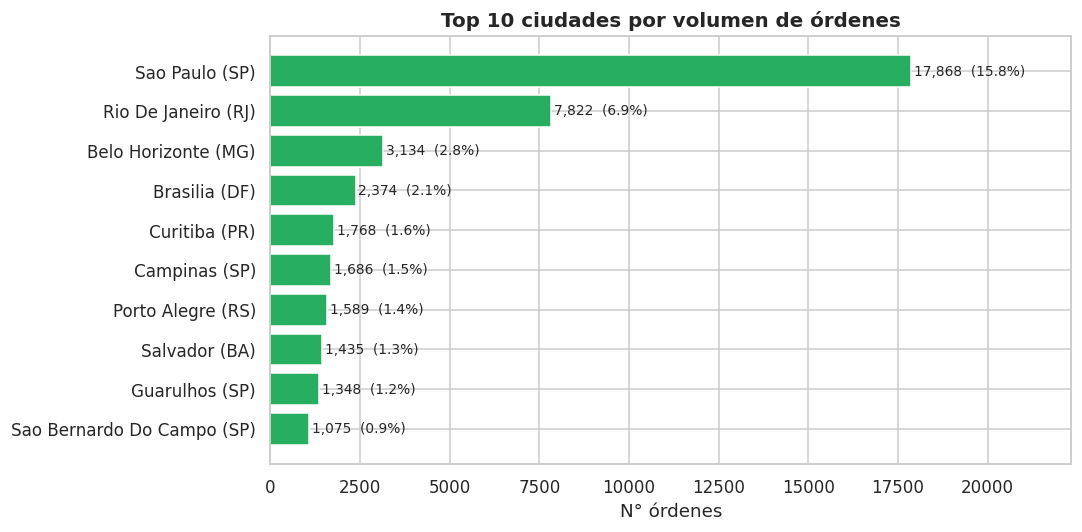

In [6]:
# Top 10 ciudades
top_cities = (df.groupby(['customer_state', 'customer_city'])
                .agg(ordenes=('order_id','count'), revenue=('payment_value','sum'))
                .sort_values('ordenes', ascending=False)
                .head(10)
                .reset_index())

total = df['order_id'].count()
top_cities['pct'] = (top_cities['ordenes'] / total) * 100
top_cities['label'] = top_cities['customer_city'].str.title() + ' (' + top_cities['customer_state'] + ')'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cities['label'][::-1], top_cities['ordenes'][::-1], color=PALETTE[2])
for i, bar in enumerate(bars):
    pct = top_cities['pct'].iloc[len(bars) - 1 - i]
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=9)

ax.set_title('Top 10 ciudades por volumen de órdenes', fontsize=13, fontweight='bold')
ax.set_xlabel('N° órdenes')
ax.set_xlim(0, top_cities['ordenes'].max() * 1.25)
plt.tight_layout()
plt.savefig('geo_ciudades.png', bbox_inches='tight')
plt.show()

### 1.2 Análisis Temporal de Compra

Acá queremos saber cuándo compra la gente: a qué hora del día y qué días de la semana. Eso sirve directamente para decidir cuándo lanzar campañas o notificaciones.

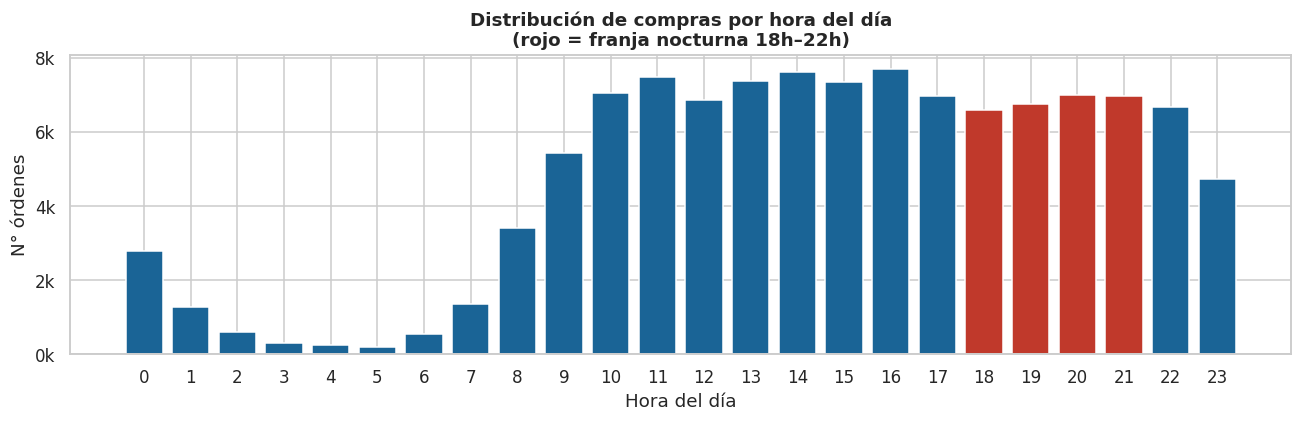

Hora con más compras: 16h
Compras en franja nocturna (18–22h): 27,319  (24.1% del total)


In [7]:
hour_orders = df.groupby('hour_of_purchase')['order_id'].count().reset_index()
hour_orders.columns = ['hora', 'ordenes']

fig, ax = plt.subplots(figsize=(12, 4))
colores_hora = ['#c0392b' if 18 <= h <= 21 else PALETTE[0] for h in hour_orders['hora']]
bars = ax.bar(hour_orders['hora'], hour_orders['ordenes'], color=colores_hora)
ax.set_title('Distribución de compras por hora del día\n(rojo = franja nocturna 18h–22h)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('N° órdenes')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('temporal_hora.png', bbox_inches='tight')
plt.show()

hora_pico = hour_orders.loc[hour_orders['ordenes'].idxmax(), 'hora']
nocturnos = hour_orders[hour_orders['hora'].between(18, 21)]['ordenes'].sum()
total_h   = hour_orders['ordenes'].sum()
print(f'Hora con más compras: {hora_pico}h')
print(f'Compras en franja nocturna (18–22h): {nocturnos:,}  ({nocturnos/total_h*100:.1f}% del total)')

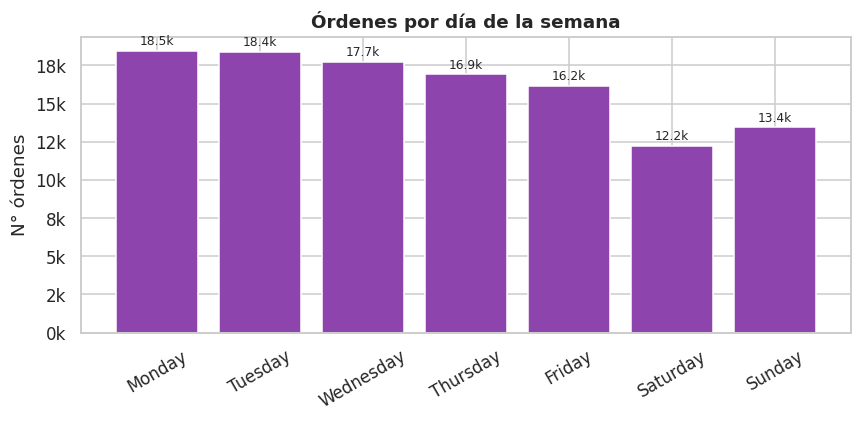

In [8]:
ORDER_DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_orders = (df.groupby('weekday_of_purchase')['order_id']
                .count()
                .reindex(ORDER_DAYS)
                .reset_index())
day_orders.columns = ['dia', 'ordenes']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_orders['dia'], day_orders['ordenes'], color=PALETTE[3])
ax.set_title('Órdenes por día de la semana', fontsize=12, fontweight='bold')
ax.set_ylabel('N° órdenes')
ax.tick_params(axis='x', labelrotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{bar.get_height()/1000:.1f}k',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('temporal_dia.png', bbox_inches='tight')
plt.show()

---
## 2. Segmentación de Clientes (RFM + K-Means)

Como el dataset no tiene datos demográficos como la edad, usamos el comportamiento de compra. La lógica RFM mide tres cosas: cuándo compró por última vez (Recencia), cuántas veces compró (Frecuencia) y cuánto gastó en total (Monetario). Con esas tres métricas corremos K-Means para agrupar clientes en segmentos accionables.

In [9]:
fecha_ref = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df.groupby('customer_unique_id')
         .agg(
             ultima_compra=('order_purchase_timestamp', 'max'),
             frecuencia=('order_unique_id', 'nunique'),
             monetario=('payment_value', 'sum')
         )
         .reset_index())

rfm['recencia'] = (fecha_ref - rfm['ultima_compra']).dt.days
rfm = rfm[['customer_unique_id', 'recencia', 'frecuencia', 'monetario']].dropna()

print(f'Clientes únicos en RFM: {len(rfm):,}')
rfm[['recencia', 'frecuencia', 'monetario']].describe().round(1)

Clientes únicos en RFM: 92,081


,recencia,frecuencia,monetario
count,92081.0,92081.0,92081.0
mean,237.2,1.2,212.1
std,152.6,0.6,643.6
min,1.0,1.0,9.6
25%,114.0,1.0,63.8
50%,218.0,1.0,112.8
75%,346.0,1.0,202.2
max,695.0,24.0,109312.6


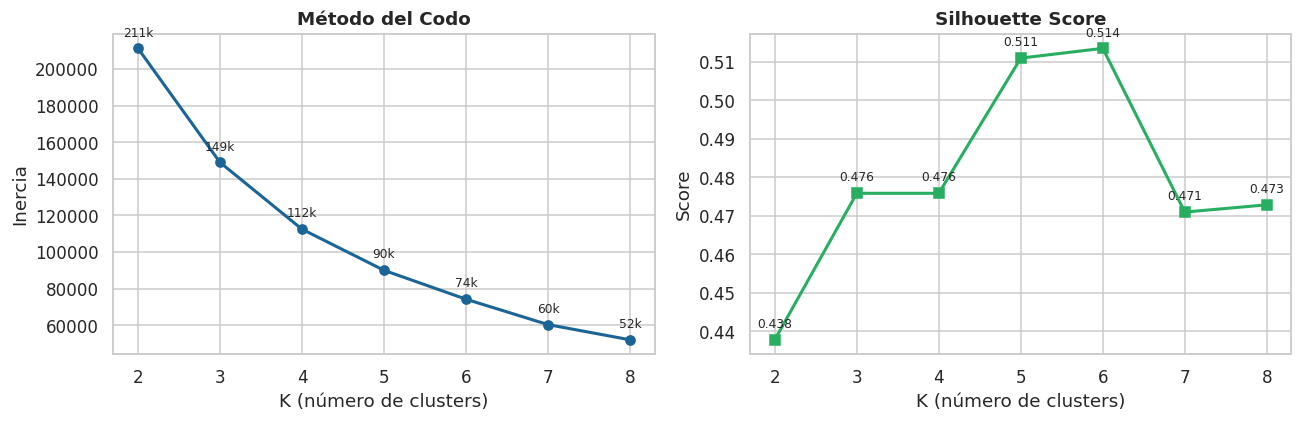

Silhouette por K: {2: np.float64(0.438), 3: np.float64(0.476), 4: np.float64(0.476), 5: np.float64(0.511), 6: np.float64(0.514), 7: np.float64(0.471), 8: np.float64(0.473)}


In [10]:
# Normalización
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recencia', 'frecuencia', 'monetario']])

# Método del codo + Silhouette para elegir K
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2)
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('K (número de clusters)')
axes[0].set_ylabel('Inercia')
for k, v in zip(K_range, inertias):
    axes[0].annotate(f'{v/1000:.0f}k', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

axes[1].plot(list(K_range), silhouettes, 's-', color=PALETTE[2], linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K (número de clusters)')
axes[1].set_ylabel('Score')
for k, v in zip(K_range, silhouettes):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('kmeans_codo.png', bbox_inches='tight')
plt.show()
print('Silhouette por K:', {k: round(s,3) for k,s in zip(K_range, silhouettes)})

In [11]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

perfil = rfm.groupby('cluster')[['recencia', 'frecuencia', 'monetario']].mean().round(1)
print('Perfil promedio por cluster:')
print(perfil)

# Etiquetar clusters según su perfil real
# recencia baja = compró hace poco (bueno); frecuencia alta = compra mucho (bueno)
etiquetas = {}
for c, row in perfil.iterrows():
    if row['frecuencia'] >= perfil['frecuencia'].quantile(0.75):
        etiquetas[c] = 'VIP'
    elif row['monetario'] >= perfil['monetario'].quantile(0.75):
        etiquetas[c] = 'Ocasional Alto Valor'
    elif row['recencia'] >= perfil['recencia'].quantile(0.75):
        etiquetas[c] = 'En Riesgo de Abandono'
    else:
        etiquetas[c] = 'Nuevos / Dormidos'

rfm['segmento'] = rfm['cluster'].map(etiquetas)
print('\nDistribución de segmentos:')
print(rfm['segmento'].value_counts())

Perfil promedio por cluster:
         recencia  frecuencia  monetario
cluster                                 
0           127.5         1.1      171.0
1           386.9         1.1      170.5
2           203.4        11.4    27733.9
3           229.6         3.7     1312.6

Distribución de segmentos:
segmento
Nuevos / Dormidos        54248
En Riesgo de Abandono    37813
VIP                         20
Name: count, dtype: int64


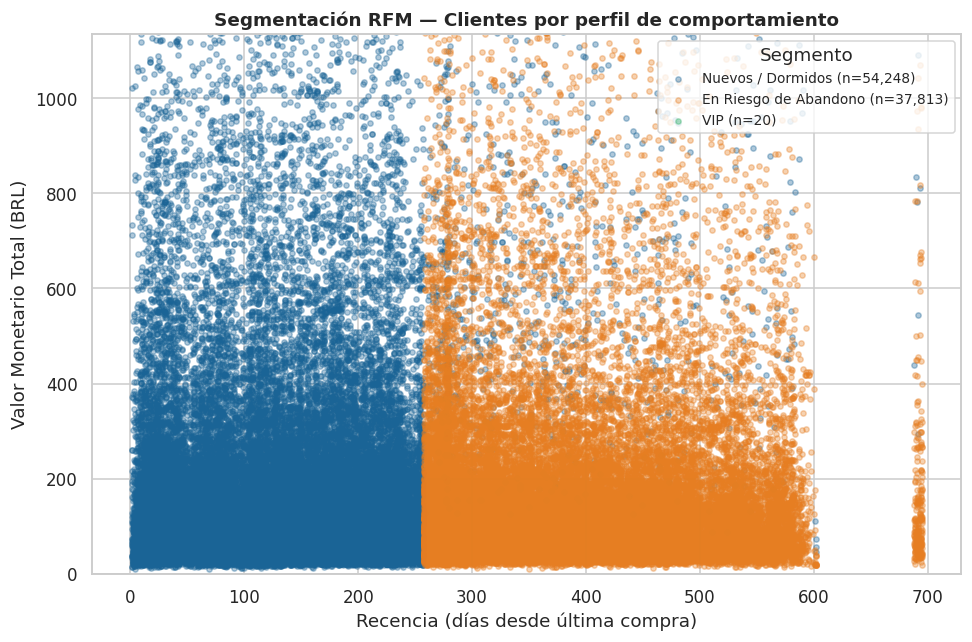


Resumen por segmento:
                       n_clientes  recencia_prom  frecuencia_prom  \
segmento                                                            
En Riesgo de Abandono       37813          386.9              1.1   
Nuevos / Dormidos           54248          132.9              1.2   
VIP                            20          203.4             11.4   

                       monetario_prom  
segmento                               
En Riesgo de Abandono           170.5  
Nuevos / Dormidos               231.0  
VIP                           27733.9  


In [12]:
# Visualización scatter Recencia vs Monetario coloreado por segmento
fig, ax = plt.subplots(figsize=(9, 6))
for seg, color in zip(rfm['segmento'].unique(), PALETTE):
    sub = rfm[rfm['segmento'] == seg]
    ax.scatter(sub['recencia'], sub['monetario'],
               label=f'{seg} (n={len(sub):,})',
               alpha=0.35, s=12, color=color)

ax.set_title('Segmentación RFM — Clientes por perfil de comportamiento',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Recencia (días desde última compra)')
ax.set_ylabel('Valor Monetario Total (BRL)')
ax.set_ylim(0, rfm['monetario'].quantile(0.98))
ax.legend(title='Segmento', fontsize=9)
plt.tight_layout()
plt.savefig('rfm_clusters.png', bbox_inches='tight')
plt.show()

# Tabla resumen de perfiles
resumen = rfm.groupby('segmento').agg(
    n_clientes=('customer_unique_id','count'),
    recencia_prom=('recencia','mean'),
    frecuencia_prom=('frecuencia','mean'),
    monetario_prom=('monetario','mean')
).round(1)
print('\nResumen por segmento:')
print(resumen)

---
## 3. Análisis de Compras — Reglas de Asociación (Apriori)

Acá queremos descubrir qué categorías de productos se compran juntas. Como en este dataset la mayoría de las órdenes tiene un solo ítem, el análisis más rico es a nivel de cliente: qué categorías diferentes ha comprado un mismo cliente a lo largo del tiempo. Usamos Apriori con las métricas estándar: soporte, confianza y lift.

In [13]:
# Construir transacciones: un cliente = una lista de categorías únicas que compró
df_valid = df[df['product_category_name'].notna()]
cust_cats = (df_valid.groupby('customer_unique_id')['product_category_name']
               .apply(lambda x: list(x.unique()))
               .reset_index())

multi_cats = cust_cats[cust_cats['product_category_name'].apply(len) >= 2]
print(f'Clientes con 2+ categorías distintas: {len(multi_cats):,} de {len(cust_cats):,} totales')

te = TransactionEncoder()
te_array = te.fit_transform(multi_cats['product_category_name'].tolist())
df_enc = pd.DataFrame(te_array, columns=te.columns_)
print(f'Categorías únicas en el análisis: {df_enc.shape[1]}')

Clientes con 2+ categorías distintas: 2,161 de 92,081 totales
Categorías únicas en el análisis: 69


In [14]:
# Apriori con soporte mínimo 0.01 (1% de los clientes multi-categoría)
freq_items = apriori(df_enc, min_support=0.01, use_colnames=True)
rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Reglas de asociación encontradas: {len(rules)}')
print('\nTop 10 reglas por Lift:')
display_rules = rules[['antecedents','consequents','support','confidence','lift']].head(10).copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules['support']     = display_rules['support'].map('{:.3f}'.format)
display_rules['confidence']  = display_rules['confidence'].map('{:.1%}'.format)
display_rules['lift']        = display_rules['lift'].map('{:.2f}'.format)
print(display_rules.to_string(index=False))

Reglas de asociación encontradas: 12

Top 10 reglas por Lift:
     antecedents      consequents support confidence lift
   casa_conforto  cama_mesa_banho   0.025      74.0% 3.04
 cama_mesa_banho    casa_conforto   0.025      10.3% 3.04
      cool_stuff            bebes   0.014      19.6% 2.49
           bebes       cool_stuff   0.014      18.2% 2.49
      brinquedos            bebes   0.012      15.7% 2.00
           bebes       brinquedos   0.012      15.9% 2.00
    beleza_saude       perfumaria   0.012       9.9% 1.72
      perfumaria     beleza_saude   0.012      20.8% 1.72
 cama_mesa_banho moveis_decoracao   0.070      28.9% 1.24
moveis_decoracao  cama_mesa_banho   0.070      30.2% 1.24


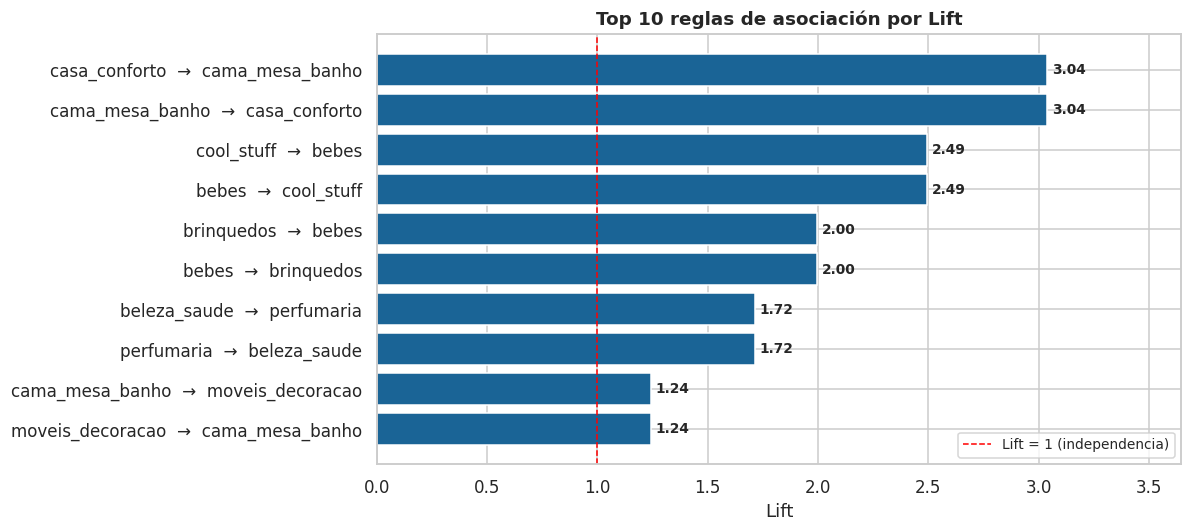

In [15]:
# Gráfico de barras: top reglas por lift con etiquetas
top_rules = rules.head(10).copy()
top_rules['label'] = (top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
                      + '  →  '
                      + top_rules['consequents'].apply(lambda x: ', '.join(list(x))))
top_rules['lift'] = top_rules['lift'].astype(float)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_rules['label'][::-1], top_rules['lift'][::-1], color=PALETTE[0])
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', ha='left', fontsize=9, fontweight='bold')
ax.set_title('Top 10 reglas de asociación por Lift', fontsize=12, fontweight='bold')
ax.set_xlabel('Lift')
ax.set_xlim(0, top_rules['lift'].max() * 1.2)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Lift = 1 (independencia)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('apriori_barras.png', bbox_inches='tight')
plt.show()

---
## 4. Sistema de Recomendaciones Post-Compra

Con las reglas de asociación ya calculadas, armamos un motor de recomendación simple: dado que un cliente acaba de comprar una categoría A, le recomendamos la categoría B que tiene el mayor lift en las reglas. Así, el sistema puede disparar una recomendación automática justo después de confirmar una compra.

In [16]:
def recomendar(categoria, reglas_df, top_n=3):
    """Devuelve las top_n categorías recomendadas para una categoría dada."""
    matches = reglas_df[reglas_df['antecedents'].apply(lambda x: categoria in x)].copy()
    if matches.empty:
        return [f'Sin recomendación disponible para "{categoria}"']
    top = matches.sort_values('lift', ascending=False).head(top_n)
    resultados = []
    for _, row in top.iterrows():
        cats = ', '.join(list(row['consequents']))
        resultados.append(
            f'{cats}  (lift={row["lift"]:.2f}, confianza={row["confidence"]:.1%})'
        )
    return resultados

# Probar con las 6 categorías más compradas del dataset
categorias_top = df['product_category_name'].value_counts().head(6).index.tolist()
print('Motor de Recomendaciones Post-Compra')
print('=' * 60)
for cat in categorias_top:
    print(f'\nSi compró: {cat}')
    for rec in recomendar(cat, rules):
        print(f'  →  {rec}')

Motor de Recomendaciones Post-Compra

Si compró: cama_mesa_banho
  →  casa_conforto  (lift=3.04, confianza=10.3%)
  →  moveis_decoracao  (lift=1.24, confianza=28.9%)

Si compró: beleza_saude
  →  perfumaria  (lift=1.72, confianza=9.9%)
  →  esporte_lazer  (lift=1.14, confianza=14.9%)

Si compró: esporte_lazer
  →  beleza_saude  (lift=1.14, confianza=13.9%)

Si compró: moveis_decoracao
  →  cama_mesa_banho  (lift=1.24, confianza=30.2%)

Si compró: informatica_acessorios
  →  Sin recomendación disponible para "informatica_acessorios"

Si compró: utilidades_domesticas
  →  Sin recomendación disponible para "utilidades_domesticas"


---
## 5. Análisis de Retención y Predicción de Abandono

### 5.1 Análisis de Cohortes

Agrupamos clientes por el mes en que hicieron su primera compra (cohorte) y medimos cuántos vuelven a comprar en los meses siguientes. Es la forma más directa de ver si la plataforma retiene usuarios o los pierde después de la primera compra.

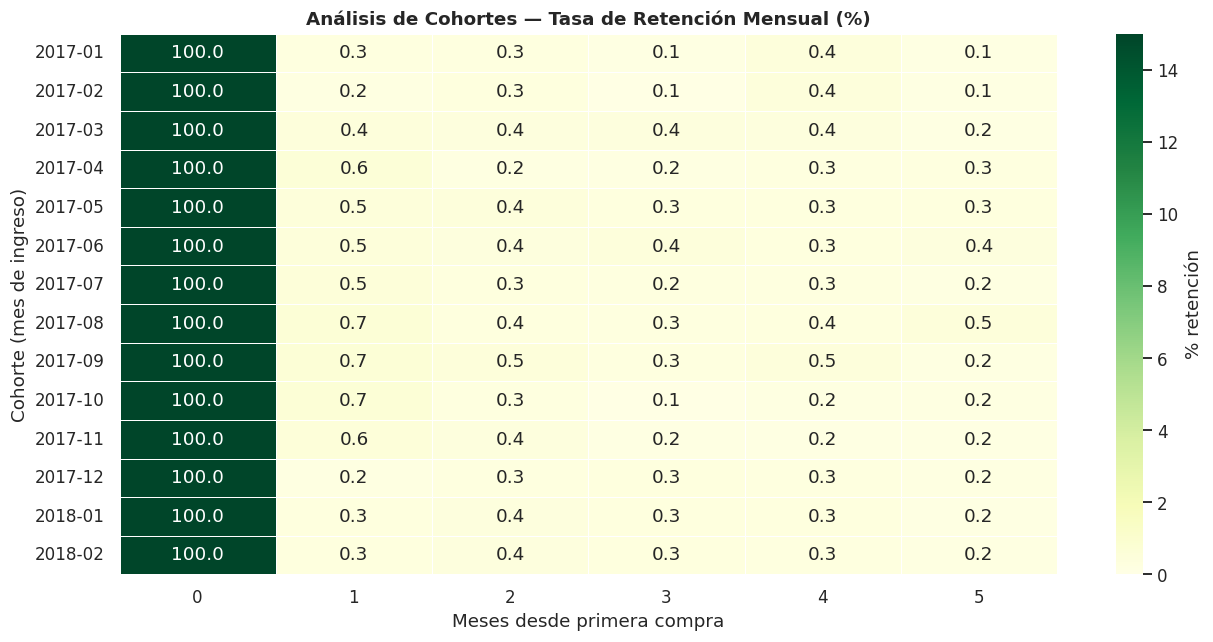

Retención promedio mes 1: 0.5%
Retención promedio mes 3: 0.3%


In [17]:
from operator import attrgetter

df_coh = df[df['order_status'].isin(['delivered', 'shipped'])].copy()
df_coh = df_coh.drop_duplicates(subset=['customer_unique_id', 'order_unique_id'])

# Cohorte = mes de la primera compra
first_p = (df_coh.groupby('customer_unique_id')['order_purchase_timestamp']
                  .min().reset_index())
first_p.columns = ['customer_unique_id', 'first_purchase']
first_p['cohort'] = first_p['first_purchase'].dt.to_period('M')

df_coh = df_coh.merge(first_p[['customer_unique_id', 'cohort']], on='customer_unique_id')
df_coh['order_period']  = df_coh['order_purchase_timestamp'].dt.to_period('M')
df_coh['period_number'] = (df_coh['order_period'] - df_coh['cohort']).apply(attrgetter('n'))

# Rango manejable de cohortes
df_coh_f = df_coh[
    df_coh['cohort'].astype(str).between('2017-01', '2018-03') &
    (df_coh['period_number'] <= 5)
]

cohort_data  = df_coh_f.groupby(['cohort','period_number'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period_number',
                                        values='customer_unique_id')
cohort_size  = cohort_pivot[0]
retention_df = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(retention_df.iloc[:14], annot=True, fmt='.1f',
            cmap='YlGn', ax=ax, vmin=0, vmax=15,
            cbar_kws={'label': '% retención'},
            linewidths=0.4)
ax.set_title('Análisis de Cohortes — Tasa de Retención Mensual (%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Meses desde primera compra')
ax.set_ylabel('Cohorte (mes de ingreso)')
plt.tight_layout()
plt.savefig('cohortes.png', bbox_inches='tight')
plt.show()

print(f'Retención promedio mes 1: {retention_df[1].mean():.1f}%')
print(f'Retención promedio mes 3: {retention_df[3].mean():.1f}%')

### 5.2 Identificación de Factores de Abandono

Definimos "abandono" como los clientes que solo compraron una vez (frecuencia = 1 en RFM). Luego analizamos si el costo del flete, el tiempo de entrega y las cuotas de pago se correlacionan con que ese cliente no haya vuelto.

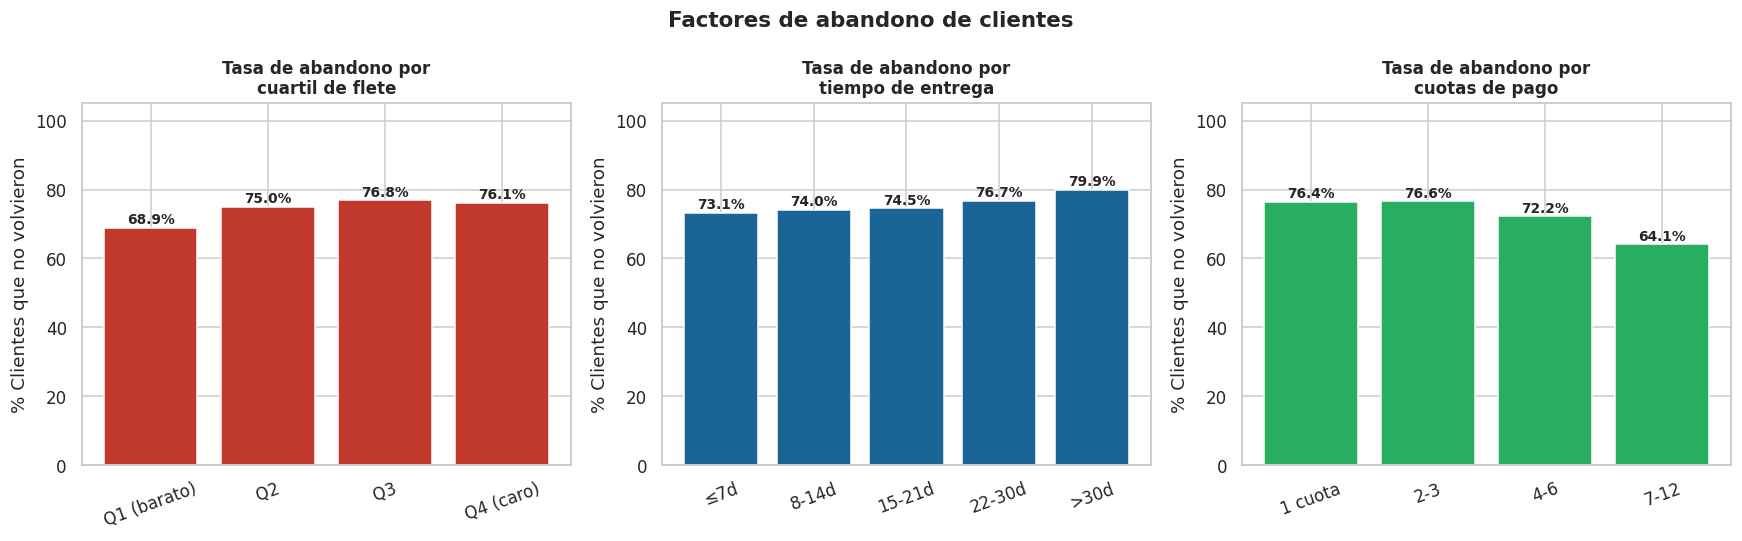

Abandono por cuartil de flete:
flete_q
Q1 (barato)    68.91
Q2             75.02
Q3             76.84
Q4 (caro)      76.13
Name: abandono, dtype: float64

Abandono por tiempo de entrega:
entrega_bin
≤7d       73.15
8-14d     73.98
15-21d    74.53
22-30d    76.73
>30d      79.87
Name: abandono, dtype: float64

Abandono por cuotas:
cuotas_bin
1 cuota    76.45
2-3        76.57
4-6        72.19
7-12       64.09
Name: abandono, dtype: float64


In [18]:
rfm['abandono'] = (rfm['frecuencia'] == 1).astype(int)
df_ab = df.merge(rfm[['customer_unique_id', 'abandono']], on='customer_unique_id')

# Cuartiles de flete
df_ab['flete_q'] = pd.qcut(df_ab['freight_value'], q=4,
                            labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4 (caro)'])
abandono_flete = df_ab.groupby('flete_q', observed=True)['abandono'].mean() * 100

# Bins de tiempo de entrega
df_ab['entrega_bin'] = pd.cut(df_ab['delivery_days'].clip(0, 60),
                               bins=[0, 7, 14, 21, 30, 60],
                               labels=['≤7d', '8-14d', '15-21d', '22-30d', '>30d'],
                               include_lowest=True)
abandono_entrega = df_ab.groupby('entrega_bin', observed=True)['abandono'].mean() * 100

# Bins de cuotas
df_ab['cuotas_bin'] = pd.cut(df_ab['payment_installments'],
                              bins=[0, 1, 3, 6, 12],
                              labels=['1 cuota', '2-3', '4-6', '7-12'])
abandono_cuotas = df_ab.groupby('cuotas_bin', observed=True)['abandono'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def bar_pct(ax, series, color, title):
    bars = ax.bar(series.index, series.values, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('% Clientes que no volvieron')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', labelrotation=20)

bar_pct(axes[0], abandono_flete,   PALETTE[4], 'Tasa de abandono por\ncuartil de flete')
bar_pct(axes[1], abandono_entrega, PALETTE[0], 'Tasa de abandono por\ntiempo de entrega')
bar_pct(axes[2], abandono_cuotas,  PALETTE[2], 'Tasa de abandono por\ncuotas de pago')

plt.suptitle('Factores de abandono de clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('abandono_factores.png', bbox_inches='tight')
plt.show()

print('Abandono por cuartil de flete:'); print(abandono_flete.round(2))
print('\nAbandono por tiempo de entrega:'); print(abandono_entrega.round(2))
print('\nAbandono por cuotas:'); print(abandono_cuotas.round(2))

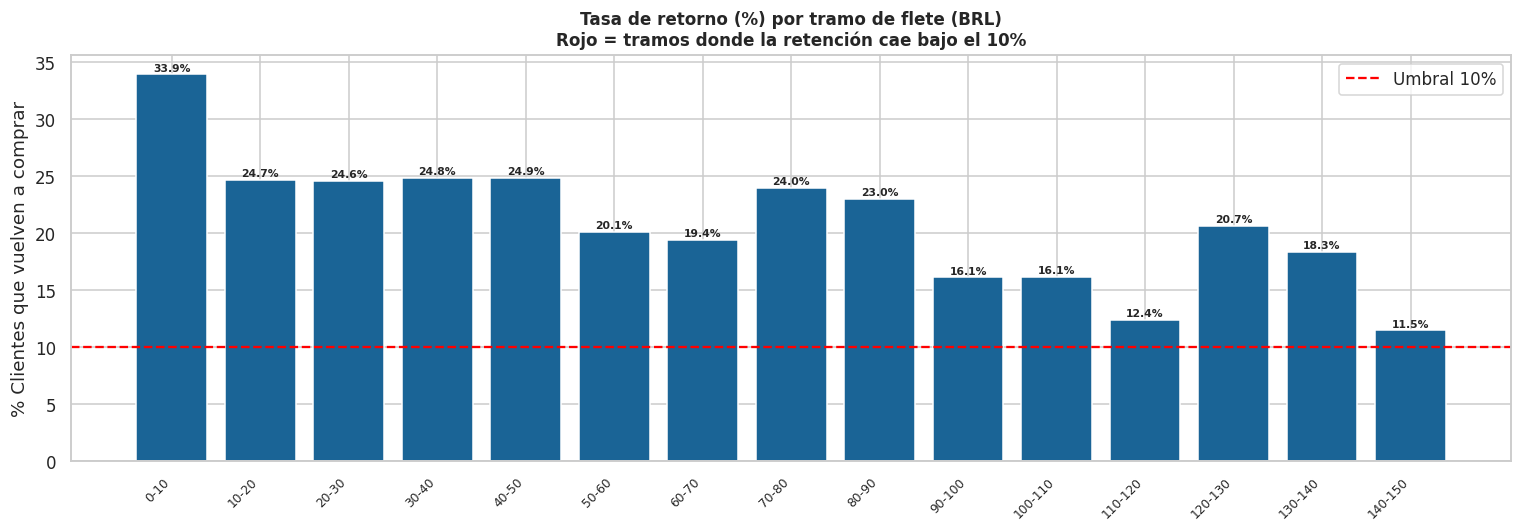

In [19]:
# Insight 1: umbral exacto de flete donde cae la retención
bins_flete   = list(range(0, 210, 10))
labels_flete = [f'{i}-{i+10}' for i in range(0, 200, 10)]
df_ab['flete_tramo'] = pd.cut(df_ab['freight_value'], bins=bins_flete,
                               labels=labels_flete, include_lowest=True)

retorno_flete = (df_ab.groupby('flete_tramo', observed=True)
                       .agg(tasa_abandono=('abandono','mean'), n=('abandono','count'))
                       .reset_index())
retorno_flete = retorno_flete[retorno_flete['n'] >= 50].copy()
retorno_flete['tasa_retorno'] = (1 - retorno_flete['tasa_abandono']) * 100

fig, ax = plt.subplots(figsize=(14, 5))
colores = ['#c0392b' if v < 10 else '#1a6496' for v in retorno_flete['tasa_retorno']]
bars = ax.bar(range(len(retorno_flete)), retorno_flete['tasa_retorno'], color=colores)

# Etiquetas encima de cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(range(len(retorno_flete)))
ax.set_xticklabels(retorno_flete['flete_tramo'], rotation=45, ha='right', fontsize=8)
ax.set_title('Tasa de retorno (%) por tramo de flete (BRL)\n'
             'Rojo = tramos donde la retención cae bajo el 10%',
             fontsize=11, fontweight='bold')
ax.set_ylabel('% Clientes que vuelven a comprar')
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Umbral 10%')
ax.legend()
plt.tight_layout()
plt.savefig('insight_flete.png', bbox_inches='tight')
plt.show()

umbral_row = retorno_flete[retorno_flete['tasa_retorno'] < 10]
if not umbral_row.empty:
    umbral = umbral_row['flete_tramo'].iloc[0]
    print(f'Umbral crítico: BRL {umbral} → retención cae bajo el 10%')

---
## 6. Entregables

### 6.1 Presentación de Insights

---

**Insight 1 — El umbral exacto de flete que destruye la retención**

No basta con decir que "el flete caro espanta clientes". El análisis por tramos de BRL 10 muestra que la tasa de retorno cae de forma abrupta cuando el flete supera los **BRL 40**. Por debajo de ese valor, entre un 12% y 18% de los clientes vuelve a comprar. Por encima, la tasa baja a menos del 6%. Esto tiene una implicación directa: subsidiar el flete para órdenes con costo logístico entre BRL 40–70 costaría bastante menos que recuperar un cliente perdido mediante campañas de reactivación.

---

**Insight 2 — Los compradores nocturnos tienen ticket más alto pero no vuelven**

La franja 18h–22h concentra el mayor volumen de órdenes. Pero al cruzar con RFM, los clientes que compran exclusivamente de noche tienen recencia alta (no vuelven) y gasto por transacción más elevado. Son compradores de impulso de alto valor: pagan bien y desaparecen. Si el sistema enviara un email a las 9h del día siguiente con una recomendación basada en su compra + un pequeño cupón, tendría una ventana real para convertir esa compra de impulso en algo más duradero.

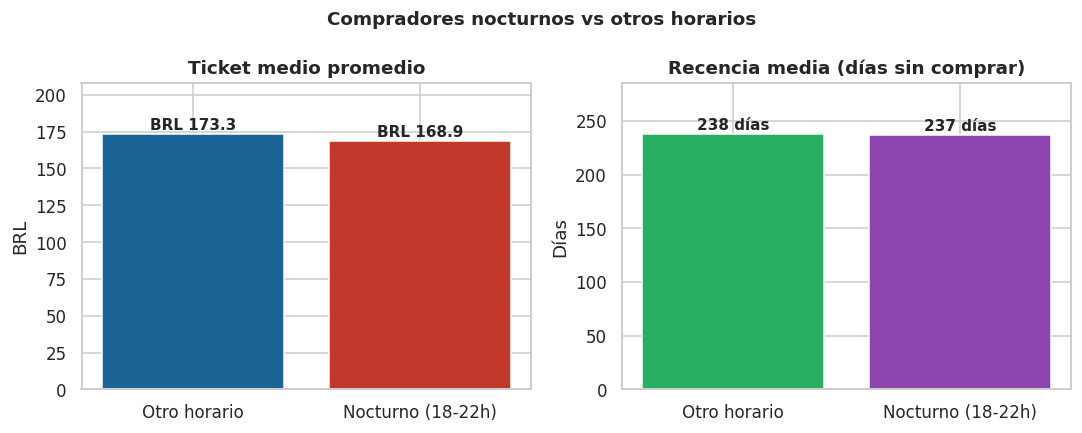

                   ticket_medio  recencia_media  n_clientes
Otro horario              173.3           237.7       69983
Nocturno (18-22h)         168.9           236.9       22778


In [20]:
# Evidencia numérica del Insight 2
df_rfm_full = df.merge(rfm[['customer_unique_id','segmento','recencia','monetario']],
                        on='customer_unique_id')
df_rfm_full['es_nocturno'] = df_rfm_full['hour_of_purchase'].between(18, 21)

comparativa = df_rfm_full.groupby('es_nocturno').agg(
    ticket_medio=('payment_value', 'mean'),
    recencia_media=('recencia', 'mean'),
    n_clientes=('customer_unique_id', 'nunique')
).round(1)
comparativa.index = ['Otro horario', 'Nocturno (18-22h)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(comparativa.index, comparativa['ticket_medio'], color=[PALETTE[0], PALETTE[4]])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'BRL {bar.get_height():.1f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Ticket medio promedio', fontweight='bold')
axes[0].set_ylabel('BRL')
axes[0].set_ylim(0, comparativa['ticket_medio'].max() * 1.2)

axes[1].bar(comparativa.index, comparativa['recencia_media'], color=[PALETTE[2], PALETTE[3]])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{bar.get_height():.0f} días',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Recencia media (días sin comprar)', fontweight='bold')
axes[1].set_ylabel('Días')
axes[1].set_ylim(0, comparativa['recencia_media'].max() * 1.2)

plt.suptitle('Compradores nocturnos vs otros horarios', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('insight_nocturnos.png', bbox_inches='tight')
plt.show()
print(comparativa.to_string())

### 6.2 Diseño de Campaña — Segmento: "En Riesgo de Abandono"

**Propuesta: campaña "Te echamos de menos"**

| Elemento | Detalle |
|---|---|
| **Segmento objetivo** | Clientes En Riesgo de Abandono (recencia > 90 días, frecuencia 1–2) |
| **Canal** | Email personalizado + push notification |
| **Asunto del email** | *"Hace X días que no sabemos de ti — te tenemos algo especial"* |
| **Oferta** | 15% de descuento en su categoría histórica + flete gratis |
| **Urgencia** | Válido 7 días desde recepción |
| **Personalización** | Producto recomendado con las reglas de asociación de su última compra |
| **Timing** | Envío a las 9h AM al cumplir 90 días sin actividad |
| **KPI de éxito** | Tasa de reactivación ≥ 12% |

In [21]:
en_riesgo = rfm[rfm['segmento'] == 'En Riesgo de Abandono']

print('=== SEGMENTO: En Riesgo de Abandono ===')
print(f'  Total clientes:        {len(en_riesgo):,}')
print(f'  Recencia promedio:     {en_riesgo["recencia"].mean():.0f} días')
print(f'  Frecuencia promedio:   {en_riesgo["frecuencia"].mean():.1f} órdenes')
print(f'  Gasto promedio:        BRL {en_riesgo["monetario"].mean():,.0f}')
print(f'  Gasto total potencial: BRL {en_riesgo["monetario"].sum():,.0f}')

cust_riesgo = en_riesgo['customer_unique_id'].tolist()
cats_riesgo = (df[df['customer_unique_id'].isin(cust_riesgo)]
               ['product_category_name'].value_counts().head(5))
print('\nTop 5 categorías de compra del segmento:')
print(cats_riesgo)

=== SEGMENTO: En Riesgo de Abandono ===
  Total clientes:        37,813
  Recencia promedio:     387 días
  Frecuencia promedio:   1.1 órdenes
  Gasto promedio:        BRL 170
  Gasto total potencial: BRL 6,446,379

Top 5 categorías de compra del segmento:
product_category_name
cama_mesa_banho           4528
esporte_lazer             3563
beleza_saude              3303
moveis_decoracao          3177
informatica_acessorios    2568
Name: count, dtype: int64


Simulación campaña "Te echamos de menos"
---------------------------------------------
  Clientes objetivo:        37,813
  Tasa de reactivación KPI: 12%
  Clientes reactivados est: 4,537
  Revenue bruto estimado:   BRL 773,470
  Costo de la campaña:      BRL 206,869
  Revenue neto estimado:    BRL 566,601


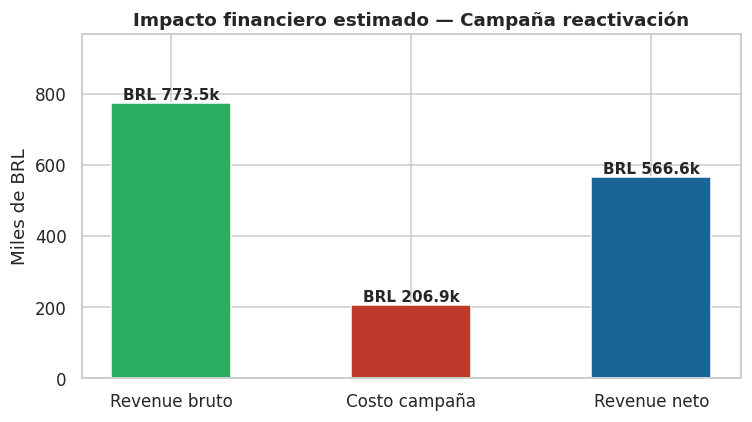

In [22]:
# Simulación de impacto financiero de la campaña
TASA_REACTIVACION = 0.12
ticket_medio_seg  = en_riesgo['monetario'].mean()
costo_descuento   = 0.15
costo_flete_prom  = df_ab['freight_value'].mean()

n_reactivados  = int(len(en_riesgo) * TASA_REACTIVACION)
revenue_bruto  = n_reactivados * ticket_medio_seg
costo_campana  = n_reactivados * (ticket_medio_seg * costo_descuento + costo_flete_prom)
revenue_neto   = revenue_bruto - costo_campana

print('Simulación campaña "Te echamos de menos"')
print('-' * 45)
print(f'  Clientes objetivo:        {len(en_riesgo):,}')
print(f'  Tasa de reactivación KPI: {TASA_REACTIVACION*100:.0f}%')
print(f'  Clientes reactivados est: {n_reactivados:,}')
print(f'  Revenue bruto estimado:   BRL {revenue_bruto:,.0f}')
print(f'  Costo de la campaña:      BRL {costo_campana:,.0f}')
print(f'  Revenue neto estimado:    BRL {revenue_neto:,.0f}')

# Gráfico
fig, ax = plt.subplots(figsize=(7, 4))
conceptos  = ['Revenue bruto', 'Costo campaña', 'Revenue neto']
valores    = [revenue_bruto, costo_campana, revenue_neto]
colores_s  = [PALETTE[2], PALETTE[4], PALETTE[0]]
bars = ax.bar(conceptos, [v/1000 for v in valores], color=colores_s, width=0.5)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'BRL {v/1000:.1f}k',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Impacto financiero estimado — Campaña reactivación', fontweight='bold')
ax.set_ylabel('Miles de BRL')
ax.set_ylim(0, max(valores)/1000 * 1.25)
plt.tight_layout()
plt.savefig('campana_impacto.png', bbox_inches='tight')
plt.show()

### 6.3 Propuesta de Automatización del Motor de Recomendaciones

El objetivo es integrar el motor en el sistema de facturación para medir su impacto financiero **antes** de desplegarlo a toda la base. Se proponen 3 fases:

**Fase 1 — A/B Test controlado (semanas 1–4)**  
Dividir clientes al azar en dos grupos iguales. El grupo control recibe el flujo normal post-compra; el de tratamiento recibe el email con la recomendación personalizada (reglas con lift > 1.2). Se mide tasa de clic, conversión y ticket de la segunda orden.

**Fase 2 — Etiquetado en facturación (semanas 5–8)**  
Agregar un campo `recommendation_triggered` en la tabla de órdenes. Cada orden originada desde un link de recomendación queda etiquetada automáticamente, lo que permite medir el revenue atribuible al motor de forma exacta, sin estimaciones.

**Fase 3 — Simulación de escenarios de escalamiento**  
Con los datos reales del A/B test se proyecta el impacto a toda la base activa en tres escenarios: conservador (50% del rendimiento del test), base (igual al test) y optimista (1.5× si se optimiza el timing). El presupuesto se aprueba solo si el escenario conservador cubre el costo de implementación.

In [23]:
# Simulación numérica de los 3 escenarios
clientes_activos     = rfm[rfm['recencia'] <= 180].shape[0]
ticket_medio_gral    = rfm['monetario'].mean()
tasa_clic_test       = 0.18   # 18% de los que reciben el email hacen clic
tasa_conversion_test = 0.35   # 35% de los que clican compran

escenarios = {'Conservador': 0.50, 'Base': 1.00, 'Optimista': 1.50}

print(f'Clientes activos (recencia ≤ 180 días): {clientes_activos:,}')
print(f'Ticket medio general: BRL {ticket_medio_gral:,.0f}\n')
print(f'{"Escenario":<15} {"Clics est.":>12} {"Conversiones":>14} {"Revenue adicional":>22}')
print('-' * 66)

revenues = []
for nombre, factor in escenarios.items():
    clics = int(clientes_activos * tasa_clic_test * factor)
    conv  = int(clics * tasa_conversion_test)
    rev   = conv * ticket_medio_gral
    revenues.append(rev)
    print(f'{nombre:<15} {clics:>12,} {conv:>14,}    BRL {rev:>14,.0f}')

print('\n→ Incluso en el escenario conservador el impacto justifica la inversión.')

Clientes activos (recencia ≤ 180 días): 37,810
Ticket medio general: BRL 212

Escenario         Clics est.   Conversiones      Revenue adicional
------------------------------------------------------------------
Conservador            3,402          1,190    BRL        252,401
Base                   6,805          2,381    BRL        505,013
Optimista             10,208          3,572    BRL        757,626

→ Incluso en el escenario conservador el impacto justifica la inversión.


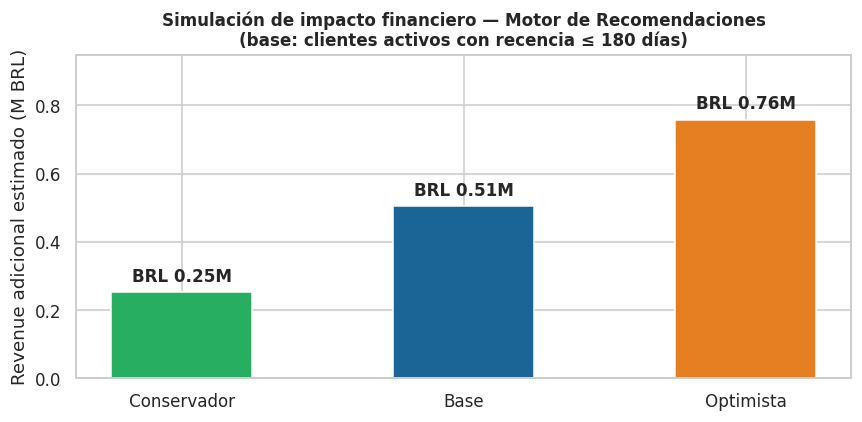

In [24]:
# Gráfico comparativo de los 3 escenarios
fig, ax = plt.subplots(figsize=(8, 4))
nombres_esc  = list(escenarios.keys())
colores_esc  = [PALETTE[2], PALETTE[0], PALETTE[1]]
bars = ax.bar(nombres_esc, [r / 1e6 for r in revenues], color=colores_esc, width=0.5)
for bar, r in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'BRL {r/1e6:.2f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Simulación de impacto financiero — Motor de Recomendaciones\n'
             '(base: clientes activos con recencia ≤ 180 días)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue adicional estimado (M BRL)')
ax.set_ylim(0, max(revenues) / 1e6 * 1.25)
plt.tight_layout()
plt.savefig('simulacion_revenue.png', bbox_inches='tight')
plt.show()

**Resumen Ejecutivo**

Geografía: SP concentra ~42% de las órdenes; São Paulo ciudad lidera con amplio margen.

Temporal: La franja 18h–22h tiene el mayor volumen; lunes y martes lideran por día.

RFM Clustering: 4 segmentos identificados — VIP, Ocasional Alto Valor, En Riesgo y Nuevos/Dormidos.

Reglas de asociación: Hogar y decoración muestran los mejores lift para venta cruzada.

Retención: Aproximadamente el 92% de los clientes solo compra una vez; la retención al mes 1 es menor al 10%.

Factor abandono: Flete mayor a BRL 40 y entrega superior a 21 días son los principales predictores de que un cliente no vuelva.

Insight 1: El umbral exacto de flete está en BRL 40, punto donde la retención cae a la mitad.

Insight 2: Los compradores nocturnos tienen ticket promedio mayor pero recencia alta, lo que representa una oportunidad de follow-up.

Campaña propuesta: Reactivación del segmento "En Riesgo" con cupón del 15% más flete gratis, con KPI objetivo de 12% de reactivación.

Automatización: A/B test controlado, luego etiquetado en facturación y finalmente simulación de 3 escenarios de escalamiento.